# IHR AS Hegemony — Top 10 Most Central ASes

[Internet Health Report](https://www.ihr.live/en/api) (IIJ Research Lab) publishes a REST API at
`https://www.ihr.live/ihr/api` (interactive docs: [`/ihr/api/docs`](https://www.ihr.live/ihr/api/docs),
schema: `/ihr/api/openapi.json`).

This notebook uses the **`/hegemony/`** endpoint. *AS Hegemony* is the estimated fraction of BGP paths
towards a destination that traverse a given transit AS — 0 means no dependency, 1 means every path goes
through it.

**Endpoint notes**

| | |
|---|---|
| Required | `timebin`, **or** both `timebin__gte` and `timebin__lte` (max 7-day span) |
| Filters | `asn` (the transit/dependency AS), `originasn` (the dependent AS), `af` (4 or 6), `hege`/`hege__gte`/`hege__lte`, `page`, `ordering` |
| Global graph | `originasn=0` → dependency of the **entire IP space** rather than of one network |
| Response | `{count, next, previous, results[]}`, each result `{timebin, originasn, asn, hege, af, asn_name, originasn_name}` |
| Gotcha | unknown query params (e.g. `format`, `limit`) are rejected with HTTP 400 |

Data is published every 15 minutes. We pull the **most recent** timebin of the global graph and rank
transit ASes by hegemony.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import requests
from datetime import datetime, timedelta, timezone

BASE = "https://www.ihr.live/ihr/api"
AF = 4            # address family: 4 or 6
ORIGINASN = 0     # 0 = global graph (dependency of the whole IP space)
TOP_N = 10

In [2]:
def ihr_get(path, **params):
    """GET an IHR endpoint, following `next` pagination, returning all results."""
    url, results = f"{BASE}{path}", []
    while url:
        r = requests.get(url, params=params, timeout=60)
        r.raise_for_status()
        payload = r.json()
        results += payload["results"]
        url, params = payload.get("next"), None   # `next` already carries the query string
    return results

## 1. Find the most recent timebin

The API has no "latest" shortcut, so we scan the last 24 hours. A `hege__gte` floor keeps the probe
response tiny — only the handful of highly central ASes come back, which is enough to learn the newest
timestamp.

In [3]:
now = datetime.now(timezone.utc)
probe = ihr_get(
    "/hegemony/",
    originasn=ORIGINASN,
    af=AF,
    timebin__gte=(now - timedelta(hours=24)).strftime("%Y-%m-%dT%H:%M"),
    timebin__lte=now.strftime("%Y-%m-%dT%H:%M"),
    hege__gte=0.05,
)

latest = max(r["timebin"] for r in probe)
print(f"{len(probe)} probe rows; most recent timebin: {latest}")

462 probe rows; most recent timebin: 2026-08-19T15:15:00Z


## 2. Fetch that timebin and rank

A single timebin of the global graph holds ~80k rows (one per transit AS), so we ask the API for only
the ones that matter with `hege__gte=0.001` — three orders of magnitude below where the top 10 sits.

Two things to filter out: `asn == -1` is a bookkeeping sentinel (the origin itself, always `hege == 1.0`),
and negative ASNs in general are IHR-internal placeholders, not real networks.

In [4]:
rows = ihr_get("/hegemony/", originasn=ORIGINASN, af=AF, timebin=latest, hege__gte=0.001)

df = pd.DataFrame(rows)
df = df[df["asn"] > 0]                                    # drop sentinel/placeholder ASNs
top = df.nlargest(TOP_N, "hege").reset_index(drop=True)
top.index += 1

print(f"{len(rows)} ASes returned above the hege floor, {len(df)} real; showing top {TOP_N}")
top[["asn", "asn_name", "hege"]].style.format({"hege": "{:.4f}"})

222 ASes returned above the hege floor, 221 real; showing top 10


,asn,asn_name,hege
1,3356,"LEVEL3 - Level 3 Parent, LLC, US",0.1965
2,1299,"TWELVE99 Arelion Sweden AB, SE",0.1406
3,749,"DNIC-AS-00749 - United States Department of Defense (DoD), US",0.0712
4,6939,"HURRICANE - Hurricane Electric LLC, US",0.0706
5,174,"COGENT-174 - Cogent Communications, LLC, US",0.0673
6,16509,"AMAZON-02 - Amazon.com, Inc., US",0.0573
7,4134,"CHINANET-BACKBONE - No.31,Jin-rong Street, CN",0.0468
8,2914,"NTT-DATA-2914 - NTT America, Inc., US",0.0359
9,7018,"ATT-INTERNET4 - AT&T Enterprises, LLC, US",0.0356
10,701,"UUNET - Verizon Business, US",0.0279


## 3. Plot

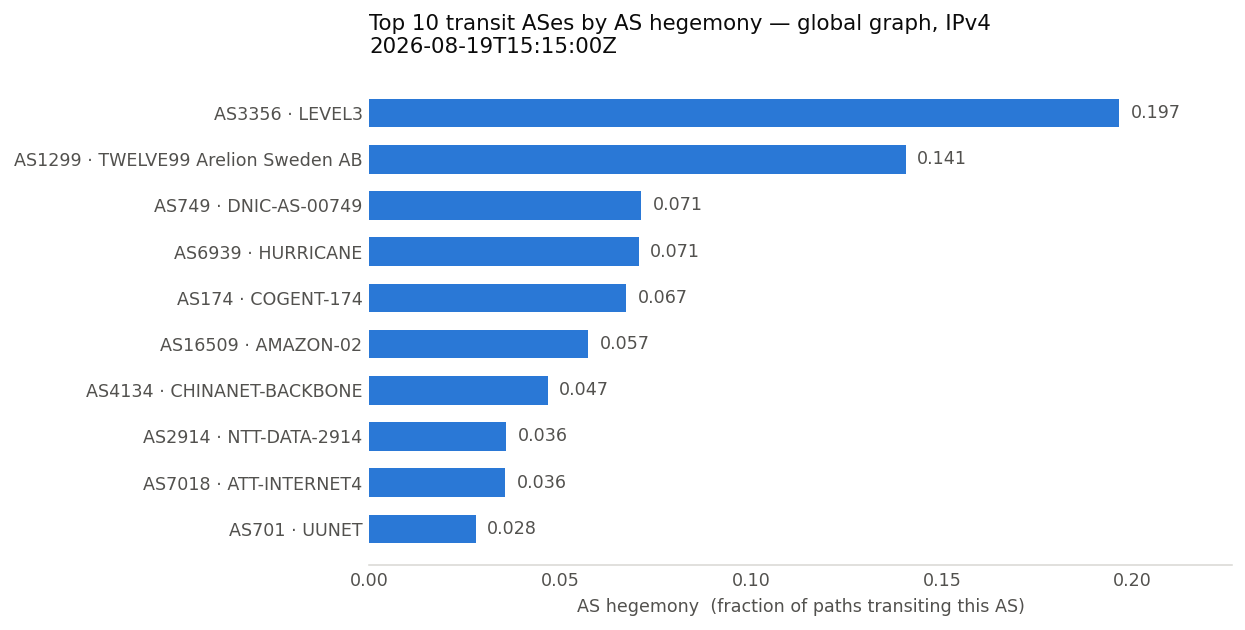

In [5]:
INK, MUTED, SERIES = "#0b0b0b", "#52514e", "#2a78d6"

plot = top.iloc[::-1]                                      # largest at the top
labels = [f"AS{a} · {n.split(' - ')[0].split(',')[0]}" for a, n in zip(plot.asn, plot.asn_name)]

fig, ax = plt.subplots(figsize=(9, 4.6), dpi=140)
ax.barh(labels, plot.hege, height=0.62, color=SERIES)

for y, v in zip(labels, plot.hege):
    ax.text(v + max(top.hege) * 0.015, y, f"{v:.3f}", va="center", fontsize=9, color=MUTED)

ax.set_xlim(0, max(top.hege) * 1.15)
ax.set_xlabel("AS hegemony  (fraction of paths transiting this AS)", fontsize=9, color=MUTED)
ax.set_title(
    f"Top {TOP_N} transit ASes by AS hegemony — global graph, IPv{AF}\n{latest}",
    fontsize=11, color=INK, loc="left", pad=12,
)
ax.tick_params(labelsize=9, colors=MUTED, length=0)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#d9d8d4")
fig.tight_layout()
plt.show()

## Variations

- `AF = 6` → the IPv6 global graph.
- `ORIGINASN = 2497` (or any ASN) → the ASes *that network* depends on, instead of the global graph.
- `asn=<ASN>` with a `timebin__gte`/`timebin__lte` range → that AS's hegemony over time.
- Related endpoints on the same API: `/hegemony/cones/`, `/hegemony/countries/`, `/hegemony/prefixes/`,
  `/hegemony/alarms/`, `/network_delay/`, `/tr_hegemony/`, `/networks/`, `/countries/`, `/disco/events/`.
- Bulk data lives at [archive.ihr.live](https://archive.ihr.live/) — use it instead of looping this API.